In [1]:
%matplotlib inline
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')
#import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report,roc_auc_score
from scipy.stats import zscore
from sklearn.preprocessing import LabelEncoder, OneHotEncoder 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from scipy.stats import iqr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# DATA PRE PROCESSING 

In [2]:
vehicles_df= pd.read_csv("vehicle.csv")

vehicles_df.head(100)

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,97,50.0,108.0,211.0,65.0,10,214.0,31.0,24.0,156,232.0,683.0,218.0,72.0,7.0,29.0,188.0,197,car
96,89,42.0,80.0,151.0,62.0,6,144.0,46.0,19.0,139,166.0,308.0,170.0,74.0,17.0,13.0,185.0,189,car
97,86,43.0,68.0,152.0,62.0,7,150.0,44.0,19.0,142,179.0,337.0,164.0,75.0,4.0,9.0,188.0,192,bus
98,95,46.0,105.0,219.0,68.0,9,201.0,33.0,23.0,148,223.0,602.0,201.0,69.0,5.0,38.0,191.0,202,car


In [3]:

label_ench = LabelEncoder() 
columns = vehicles_df.columns

print(columns)
vehicles_df['class'] = label_ench.fit_transform(vehicles_df['class'])
vehicles_df.shape

Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity',
       'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'skewness_about.2', 'hollows_ratio', 'class'],
      dtype='object')


(846, 19)

In [4]:
# Find any Missging Values
vehicles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows_ratio    

# Observations 
    
  ## 1. Except the following attributes compactness,max.length_aspect_ratio,hollows_ratio and class we have missing values .Treat them.
  ## 2.All the attributes are either float or int

In [5]:
# Find and Treat Missing values

In [6]:
treated_vehicle_df = vehicles_df.copy()

X = treated_vehicle_df.iloc[:,0:19] 

imputer = SimpleImputer(missing_values=np.nan, strategy='median', verbose=1)
#fill missing values with mean column values
transformed_values = imputer.fit_transform(X)
column = X.columns
print(column)
treated_vehicle_df = pd.DataFrame(transformed_values, columns = column )
treated_vehicle_df.describe()

Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity',
       'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'skewness_about.2', 'hollows_ratio', 'class'],
      dtype='object')


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
count,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000
mean,93.678487,44.823877,82.100473,168.874704,61.677305,8.567376,168.887707,40.936170,20.580378,147.998818,188.596927,439.314421,174.706856,72.443262,6.361702,12.600473,188.918440,195.632388,0.977541
std,8.234474,6.134272,15.741569,33.401356,7.882188,4.601217,33.197710,7.811882,2.588558,14.515652,31.360427,176.496341,32.546277,7.468734,4.903244,8.930962,6.152247,7.438797,0.702130
min,73.000000,33.000000,40.000000,104.000000,47.000000,2.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,109.000000,59.000000,0.000000,0.000000,176.000000,181.000000,0.000000
25%,87.000000,40.000000,70.000000,141.000000,57.000000,7.000000,147.000000,33.000000,19.000000,137.000000,167.000000,318.250000,149.000000,67.000000,2.000000,5.000000,184.000000,190.250000,0.000000
50%,93.000000,44.000000,80.000000,167.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,179.000000,363.500000,173.500000,71.500000,6.000000,11.000000,188.000000,197.000000,1.000000
75%,100.000000,49.000000,98.000000,195.000000,65.000000,10.000000,198.000000,46.000000,23.000000,159.000000,217.000000,586.750000,198.000000,75.000000,9.000000,19.000000,193.000000,201.000000,1.000000
max,119.000000,59.000000,112.000000,333.000000,138.000000,55.000000,265.000000,61.000000,29.000000,188.000000,320.000000,1018.000000,268.000000,135.000000,22.000000,41.000000,206.000000,211.000000,2.000000


In [7]:
print("Original null value count:", vehicles_df.isnull().sum())
print("\n\nCount after we impiuted the NaN value: ", treated_vehicle_df.isnull().sum())

Original null value count: compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64


Count after we impiuted the NaN value:  compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity     

# Observations 
## All the null values are elimnated using "Mode" strategy

In [8]:
# Descriptive statistics

In [9]:
treated_vehicle_df.describe().T

,count,mean,std,min,25%,50%,75%,max
compactness,846.0,93.678487,8.234474,73.0,87.00,93.0,100.00,119.0
circularity,846.0,44.823877,6.134272,33.0,40.00,44.0,49.00,59.0
distance_circularity,846.0,82.100473,15.741569,40.0,70.00,80.0,98.00,112.0
radius_ratio,846.0,168.874704,33.401356,104.0,141.00,167.0,195.00,333.0
pr.axis_aspect_ratio,846.0,61.677305,7.882188,47.0,57.00,61.0,65.00,138.0
max.length_aspect_ratio,846.0,8.567376,4.601217,2.0,7.00,8.0,10.00,55.0
scatter_ratio,846.0,168.887707,33.197710,112.0,147.00,157.0,198.00,265.0
elongatedness,846.0,40.936170,7.811882,26.0,33.00,43.0,46.00,61.0
pr.axis_rectangularity,846.0,20.580378,2.588558,17.0,19.00,20.0,23.00,29.0
max.length_rectangularity,846.0,147.998818,14.515652,118.0,137.00,146.0,159.00,188.0


In [10]:
treated_vehicle_df.shape

(846, 19)

# Observations
## 1.compactness,circularity,distance_circularity,pr.axis_rectangularity,scaled_radius_of_gyration,
##   skewness_about,skewness_about.2 seems to be normal
## 2.scatter_ratio may have some outliers

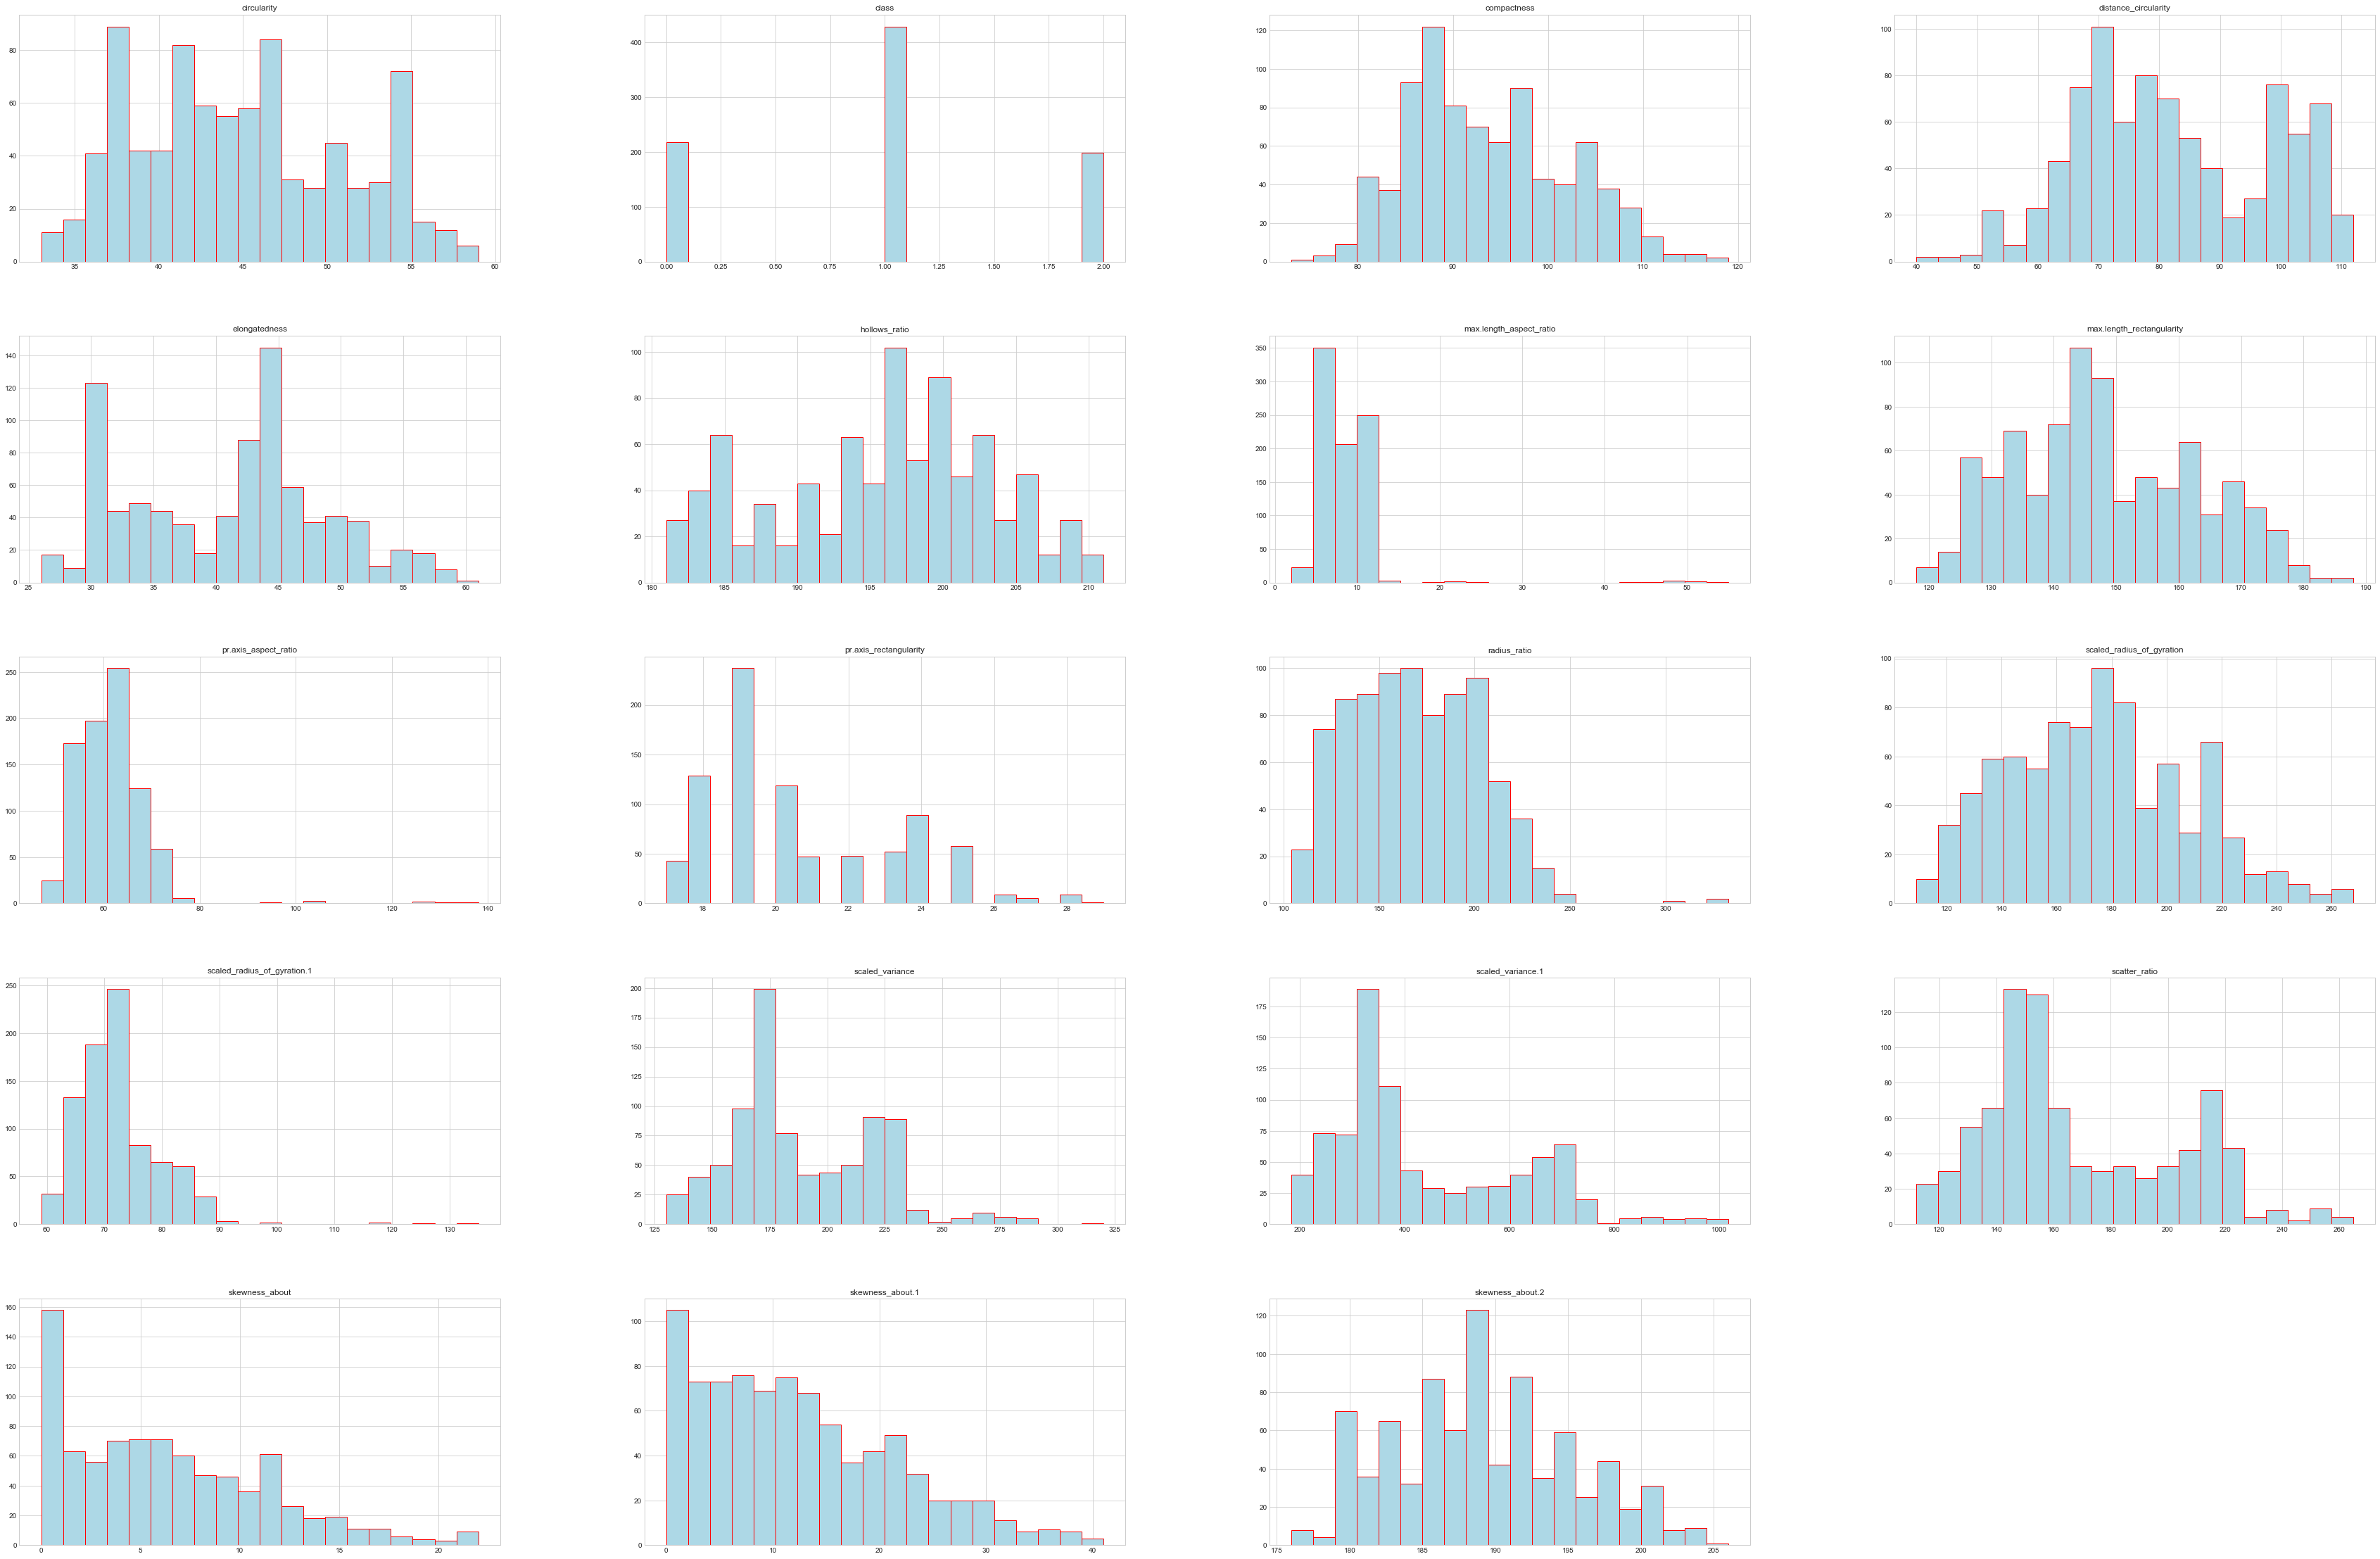

In [11]:
plt.style.use('seaborn-whitegrid')

treated_vehicle_df.hist(bins=20, figsize=(60,40), color='lightblue', edgecolor = 'red')
plt.show()

# Observations
## 1.pr.axis_rectangularity may have  outliers as there are some gaps found in the bar plot.
## 2.Right skewed skewness_about1.1,scatter_ratio,scaled_variance.1,scaled_variance,


# Univariate Analysis 

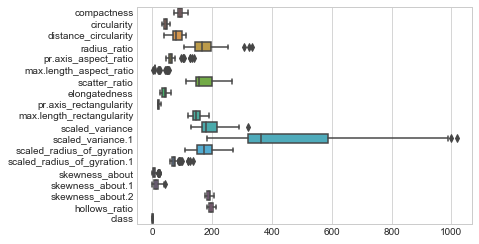

In [12]:
ax = sns.boxplot(data=treated_vehicle_df, orient="h")

In [13]:
## Too smallto view let us blow up

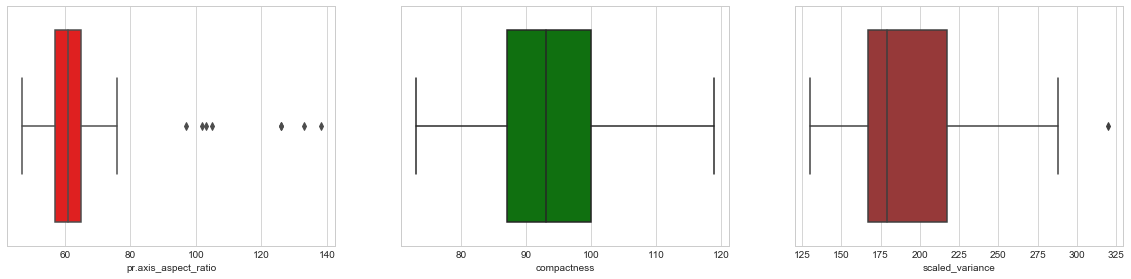

In [14]:
plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
sns.boxplot(x= treated_vehicle_df["pr.axis_aspect_ratio"], color='red')

plt.subplot(3,3,2)
sns.boxplot(x= treated_vehicle_df.compactness, color='green')

plt.subplot(3,3,3)
sns.boxplot(x= treated_vehicle_df.scaled_variance, color='brown')

plt.show()

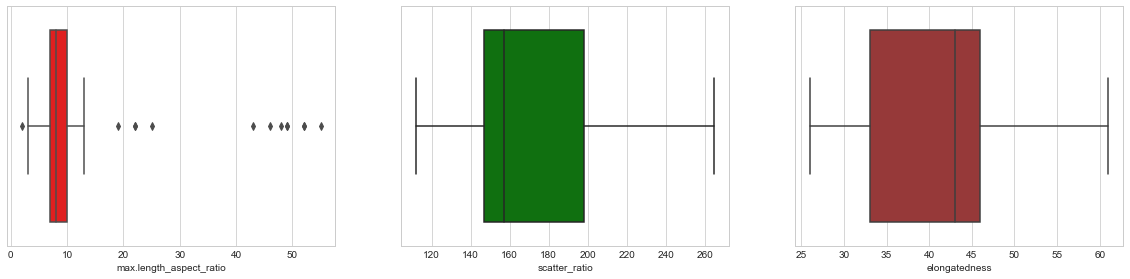

In [15]:
plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
sns.boxplot(x= treated_vehicle_df["max.length_aspect_ratio"], color='red')

plt.subplot(3,3,2)
sns.boxplot(x= treated_vehicle_df.scatter_ratio, color='green')

plt.subplot(3,3,3)
sns.boxplot(x= treated_vehicle_df.elongatedness, color='brown')

plt.show()

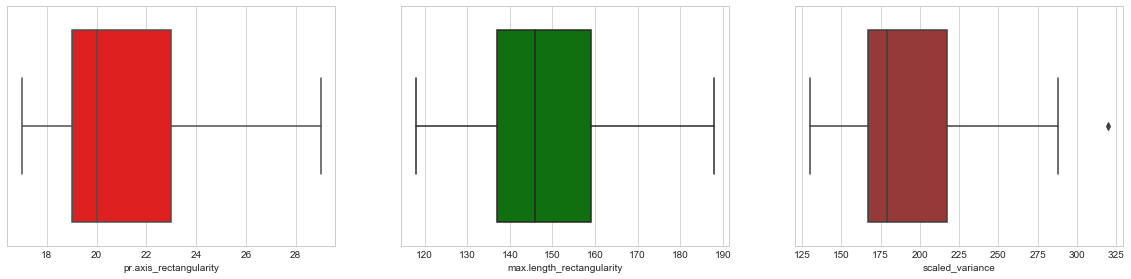

In [16]:
plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
sns.boxplot(x= treated_vehicle_df["pr.axis_rectangularity"], color='red')



plt.subplot(3,3,2)
sns.boxplot(x= treated_vehicle_df["max.length_rectangularity"], color='green')

plt.subplot(3,3,3)
sns.boxplot(x= treated_vehicle_df.scaled_variance, color='brown')

plt.show()

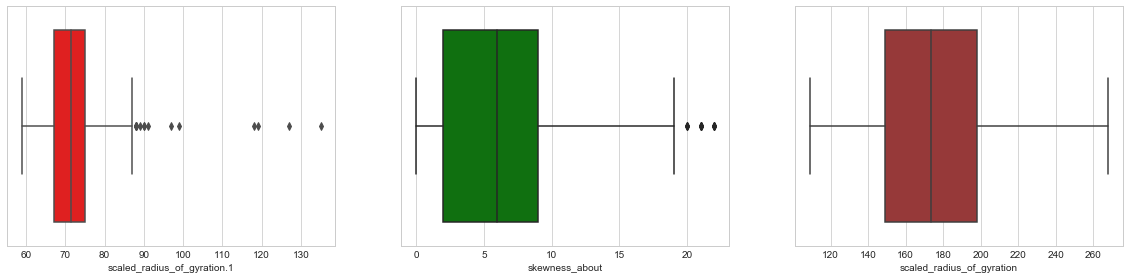

In [17]:
plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
sns.boxplot(x= treated_vehicle_df["scaled_radius_of_gyration.1"], color='red')



plt.subplot(3,3,2)
sns.boxplot(x= treated_vehicle_df["skewness_about"], color='green')

plt.subplot(3,3,3)
sns.boxplot(x= treated_vehicle_df.scaled_radius_of_gyration, color='brown')

plt.show()

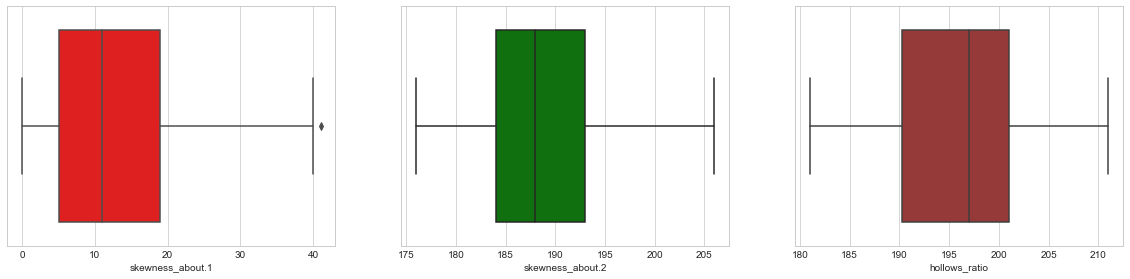

In [18]:
plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
sns.boxplot(x= treated_vehicle_df["skewness_about.1"], color='red')



plt.subplot(3,3,2)
sns.boxplot(x= treated_vehicle_df["skewness_about.2"], color='green')

plt.subplot(3,3,3)
sns.boxplot(x= treated_vehicle_df.hollows_ratio, color='brown')

plt.show()

# Observations
## 1.Outliers and skewness found in skewness_about.1,skewness_about,scaled_radius_of_gyration.1,     max.length_aspect_ratio,pr.axis_aspect_ratio,scaled_variance has dotted points 

# Treating Outliers using IQR

In [19]:
Q1 = treated_vehicle_df.quantile(0.25)
Q3 = treated_vehicle_df.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

compactness                     13.00
circularity                      9.00
distance_circularity            28.00
radius_ratio                    54.00
pr.axis_aspect_ratio             8.00
max.length_aspect_ratio          3.00
scatter_ratio                   51.00
elongatedness                   13.00
pr.axis_rectangularity           4.00
max.length_rectangularity       22.00
scaled_variance                 50.00
scaled_variance.1              268.50
scaled_radius_of_gyration       49.00
scaled_radius_of_gyration.1      8.00
skewness_about                   7.00
skewness_about.1                14.00
skewness_about.2                 9.00
hollows_ratio                   10.75
class                            1.00
dtype: float64


In [20]:
outliers_removed_df = treated_vehicle_df[~((treated_vehicle_df < (Q1 - 1.5 * IQR)) |(treated_vehicle_df > (Q3 + 1.5 * IQR))).any(axis=1)]
outliers_removed_df.shape

(813, 19)

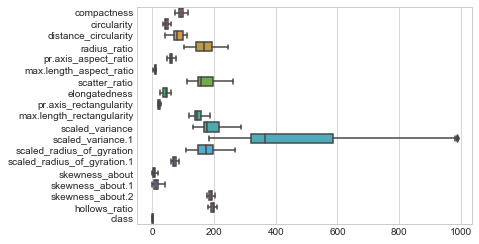

In [21]:
ax = sns.boxplot(data=outliers_removed_df, orient="h")

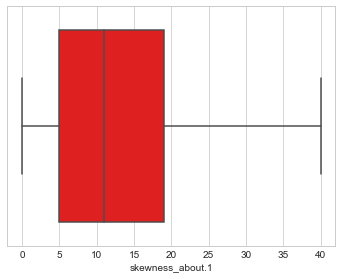

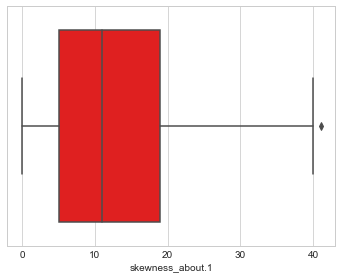

In [22]:
plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
sns.boxplot(x= outliers_removed_df["skewness_about.1"], color='red')

plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
sns.boxplot(x= treated_vehicle_df["skewness_about.1"], color='red')

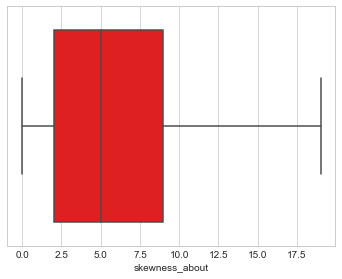

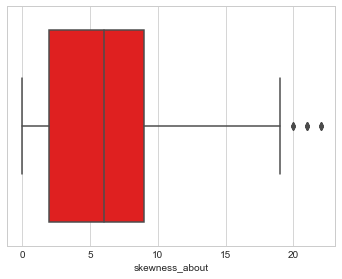

In [23]:
plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
sns.boxplot(x= outliers_removed_df["skewness_about"], color='red')

plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
sns.boxplot(x= treated_vehicle_df["skewness_about"], color='red')


# Observations 
## All the outliers are cleaned up

# UNDERSTANDING ATTRIBUTES

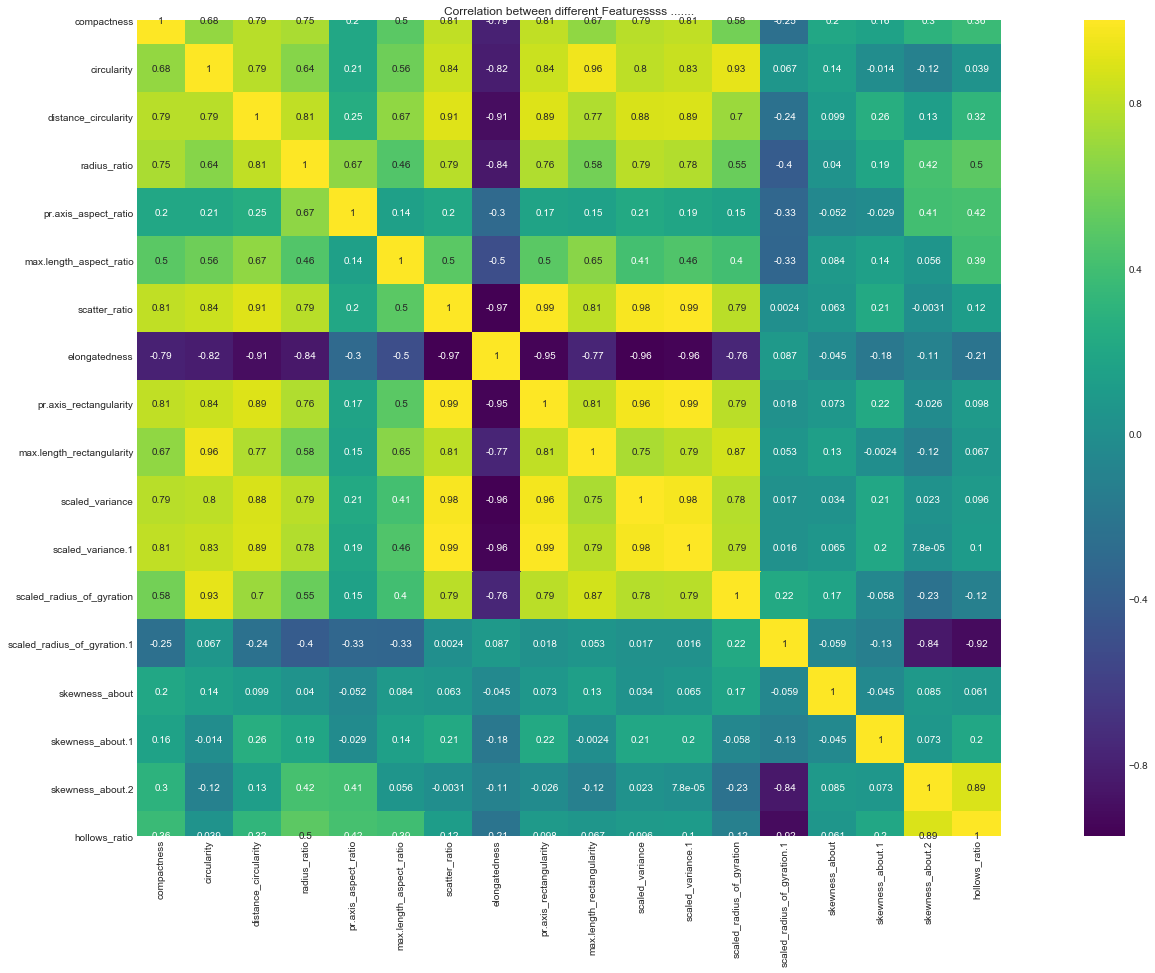

In [24]:
def correlation_heatmap(dataframe,l,w):
    
    correlation = dataframe.corr()
    plt.figure(figsize=(l,w))
    sns.heatmap(correlation, vmax=1, square=True,annot=True,cmap='viridis')
    plt.title('Correlation between different Featuressss .......')
    plt.show();
    
# Remove class 
cleandf= outliers_removed_df.drop('class', axis=1)
#print("After Dropping: ", cleandf)
correlation_heatmap(cleandf, 30,15)

# Observations

## Strong positive Correlation 
### 1. scaled_variance & scaled_variance.1 0.98
### 2. scaled_variance.1 & pr.axis_rectangularity 0.99
### 3. scatter_ratio & pr.axis_rectangularity 0.99
### 4. scatter_ratio & scaled_variance.1 0.99


## Strong Negative Correlation

### 1.Elongatedness seems to have negative correlation with scaled_radius_of_gyration,scaled_variance.1,pr.axis_rectangularity,scatter_ratio


# Choosing Right Attributes

From above correlation matrix we can see that there are many features which are highly correlated. We will find that many features are there which having more than 0.9 correlation.  we can decide to get rid of those columns whose correlation is +-0.9 or above.There are 8 such columns:

max.length_rectangularity
scaled_radius_of_gyration
skewness_about.2
scatter_ratio
elongatedness
pr.axis_rectangularity
scaled_variance
scaled_variance.1 


But instead let us use PCA.

# PCA



In [25]:
pca_df =outliers_removed_df.copy()

In [26]:
pca_df.head(850)

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95.0,48.0,83.0,178.0,72.0,10.0,162.0,42.0,20.0,159.0,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197.0,2.0
1,91.0,41.0,84.0,141.0,57.0,9.0,149.0,45.0,19.0,143.0,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199.0,2.0
2,104.0,50.0,106.0,209.0,66.0,10.0,207.0,32.0,23.0,158.0,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196.0,1.0
3,93.0,41.0,82.0,159.0,63.0,9.0,144.0,46.0,19.0,143.0,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207.0,2.0
5,107.0,44.0,106.0,172.0,50.0,6.0,255.0,26.0,28.0,169.0,280.0,957.0,264.0,85.0,5.0,9.0,181.0,183.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,93.0,39.0,87.0,183.0,64.0,8.0,169.0,40.0,20.0,134.0,200.0,422.0,149.0,72.0,7.0,25.0,188.0,195.0,1.0
842,89.0,46.0,84.0,163.0,66.0,11.0,159.0,43.0,20.0,159.0,173.0,368.0,176.0,72.0,1.0,20.0,186.0,197.0,2.0
843,106.0,54.0,101.0,222.0,67.0,12.0,222.0,30.0,25.0,173.0,228.0,721.0,200.0,70.0,3.0,4.0,187.0,201.0,1.0
844,86.0,36.0,78.0,146.0,58.0,7.0,135.0,50.0,18.0,124.0,155.0,270.0,148.0,66.0,0.0,25.0,190.0,195.0,1.0


In [27]:
# Seperate out the class variable
X = pca_df.iloc[:,0:18].values
Y = pca_df.iloc[:,18].values
X

array([[ 95.,  48.,  83., ...,  16., 187., 197.],
       [ 91.,  41.,  84., ...,  14., 189., 199.],
       [104.,  50., 106., ...,   9., 188., 196.],
       ...,
       [106.,  54., 101., ...,   4., 187., 201.],
       [ 86.,  36.,  78., ...,  25., 190., 195.],
       [ 85.,  36.,  66., ...,  18., 186., 190.]])

In [28]:
sc = StandardScaler()
X_std =  sc.fit_transform(X) 

In [29]:
cov_matrix = np.cov(X_std.T)
print("cov_matrix shape:",cov_matrix.shape)
print("Covariance_matrix",cov_matrix)

cov_matrix shape: (18, 18)
Covariance_matrix [[ 1.00123153e+00  6.80164027e-01  7.87792814e-01  7.46906930e-01
   2.00881439e-01  4.98273207e-01  8.11840645e-01 -7.89531434e-01
   8.12866245e-01  6.74996601e-01  7.92438680e-01  8.13494150e-01
   5.78399755e-01 -2.53990635e-01  2.00887113e-01  1.61304844e-01
   2.95777412e-01  3.64608943e-01]
 [ 6.80164027e-01  1.00123153e+00  7.87747162e-01  6.41725205e-01
   2.06409699e-01  5.64854067e-01  8.44804611e-01 -8.16768295e-01
   8.41196310e-01  9.62404205e-01  8.03750964e-01  8.33508154e-01
   9.26281607e-01  6.67790806e-02  1.40563881e-01 -1.43598307e-02
  -1.16976151e-01  3.92302597e-02]
 [ 7.87792814e-01  7.87747162e-01  1.00123153e+00  8.09326627e-01
   2.45756551e-01  6.69657073e-01  9.06692225e-01 -9.09806087e-01
   8.95884623e-01  7.69635504e-01  8.85221631e-01  8.89286924e-01
   7.03348558e-01 -2.38231284e-01  9.89345733e-02  2.63832735e-01
   1.29070982e-01  3.22051625e-01]
 [ 7.46906930e-01  6.41725205e-01  8.09326627e-01  1.00123

In [30]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-2.72251046e-01 -8.97284818e-02  2.26045073e-02  1.30419032e-01
  -1.52324139e-01  2.58374578e-01 -1.88794221e-01 -7.71578238e-01
  -3.61784776e-01 -1.25233628e-01  2.92009470e-02  7.62442008e-04
  -1.06680587e-02  1.05983722e-02 -1.01407495e-01 -1.46326861e-01
  -3.81638532e-03  3.32992130e-03]
 [-2.85370045e-01  1.33173937e-01  2.10809943e-01 -2.06785531e-02
   1.39022591e-01 -6.88979940e-02  3.90871235e-01 -6.60528436e-02
  -4.62957583e-02  2.40262612e-01  7.29503235e-02  1.93799916e-01
  -7.74670931e-03 -8.71766559e-02 -3.11337823e-01  1.96463651e-01
  -2.96230720e-01  5.83996136e-01]
 [-3.01486231e-01 -4.40259591e-02 -7.08780817e-02  1.07425217e-01
   8.07335409e-02 -2.04800896e-02 -1.76384547e-01  2.98693883e-01
  -2.64499195e-01 -9.42971834e-02  7.78755026e-01 -2.32649049e-01
   1.11905744e-02  2.28724292e-02  5.89166755e-02  5.33931974e-02
   9.72735293e-02  8.64160083e-02]
 [-2.72594510e-01 -2.04232234e-01 -4.02139629e-02 -2.52957341e-01
  -1.19012554e-01 -

In [31]:
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(9.792975698382946, array([-0.27225105, -0.28537005, -0.30148623, -0.27259451, -0.09857976,
       -0.19475579, -0.31051844,  0.30843834, -0.30754849, -0.27630107,
       -0.30274811, -0.30704063, -0.26152049,  0.04363236, -0.0367057 ,
       -0.05885041, -0.03483739, -0.08281362])), (3.377106439893973, array([-0.08972848,  0.13317394, -0.04402596, -0.20423223, -0.25913686,
       -0.09457563,  0.07233508, -0.01168768,  0.08409153,  0.12583663,
        0.07019986,  0.07793366,  0.20992728,  0.50391445, -0.01456825,
       -0.09339805, -0.50166421, -0.50654656])), (1.2087305396350991, array([ 0.02260451,  0.21080994, -0.07087808, -0.04021396,  0.11480523,
        0.13931348, -0.1129247 ,  0.09003305, -0.11106355,  0.21987769,
       -0.14481876, -0.11532395,  0.21362744, -0.06739209,  0.52162344,
       -0.68717064,  0.06220695,  0.04080354])), (1.1365956021766952, array([ 0.13041903, -0.02067855,  0.10742522, -0.25295734, -0.605228  ,
        0.32253141, -0.01005404,  0.07991176,  0.0

In [32]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  
cum_var_exp = np.cumsum(var_explained) 

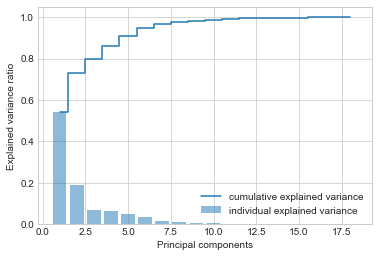

In [33]:
plt.bar(range(1,19), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,19),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

# Observation :

Cleary we see around 8 dimensions are explaining 95% variance

# Dimensionality Reduction using 8 compoents

In [34]:
reduced = np.array(eigvectors_sorted[0:8])   

X_std_8D = np.dot(X_std,reduced.T)   

reduced_pca = pd.DataFrame(X_std_8D)  

reduced_pca

,0,1,2,3,4,5,6,7
0,-0.591125,-0.655523,0.564477,-0.659870,0.855251,-1.835814,0.155983,-0.683144
1,1.524878,-0.327117,0.251528,1.296236,0.282463,-0.091649,-0.209862,0.127745
2,-3.969982,0.239514,1.229875,0.180391,-0.919360,-0.650638,-0.826445,0.163185
3,1.549729,-3.037566,0.466449,0.394413,0.623392,0.383794,-0.131539,-0.176248
4,-5.468963,4.651385,-1.290061,0.023804,-1.692033,2.510965,-0.315330,0.475009
...,...,...,...,...,...,...,...,...
808,0.368201,-0.641878,-1.481101,0.164090,-0.777381,-0.934650,-0.874360,0.193428
809,0.040917,-0.160848,-0.473839,-0.179208,1.978454,-1.431609,0.279248,-0.302916
810,-5.188919,-0.171319,0.585738,-0.886837,1.348744,0.225891,-0.888525,-0.429704
811,3.321748,-1.094132,-1.930953,0.339361,0.527587,-0.030116,0.265542,0.451123


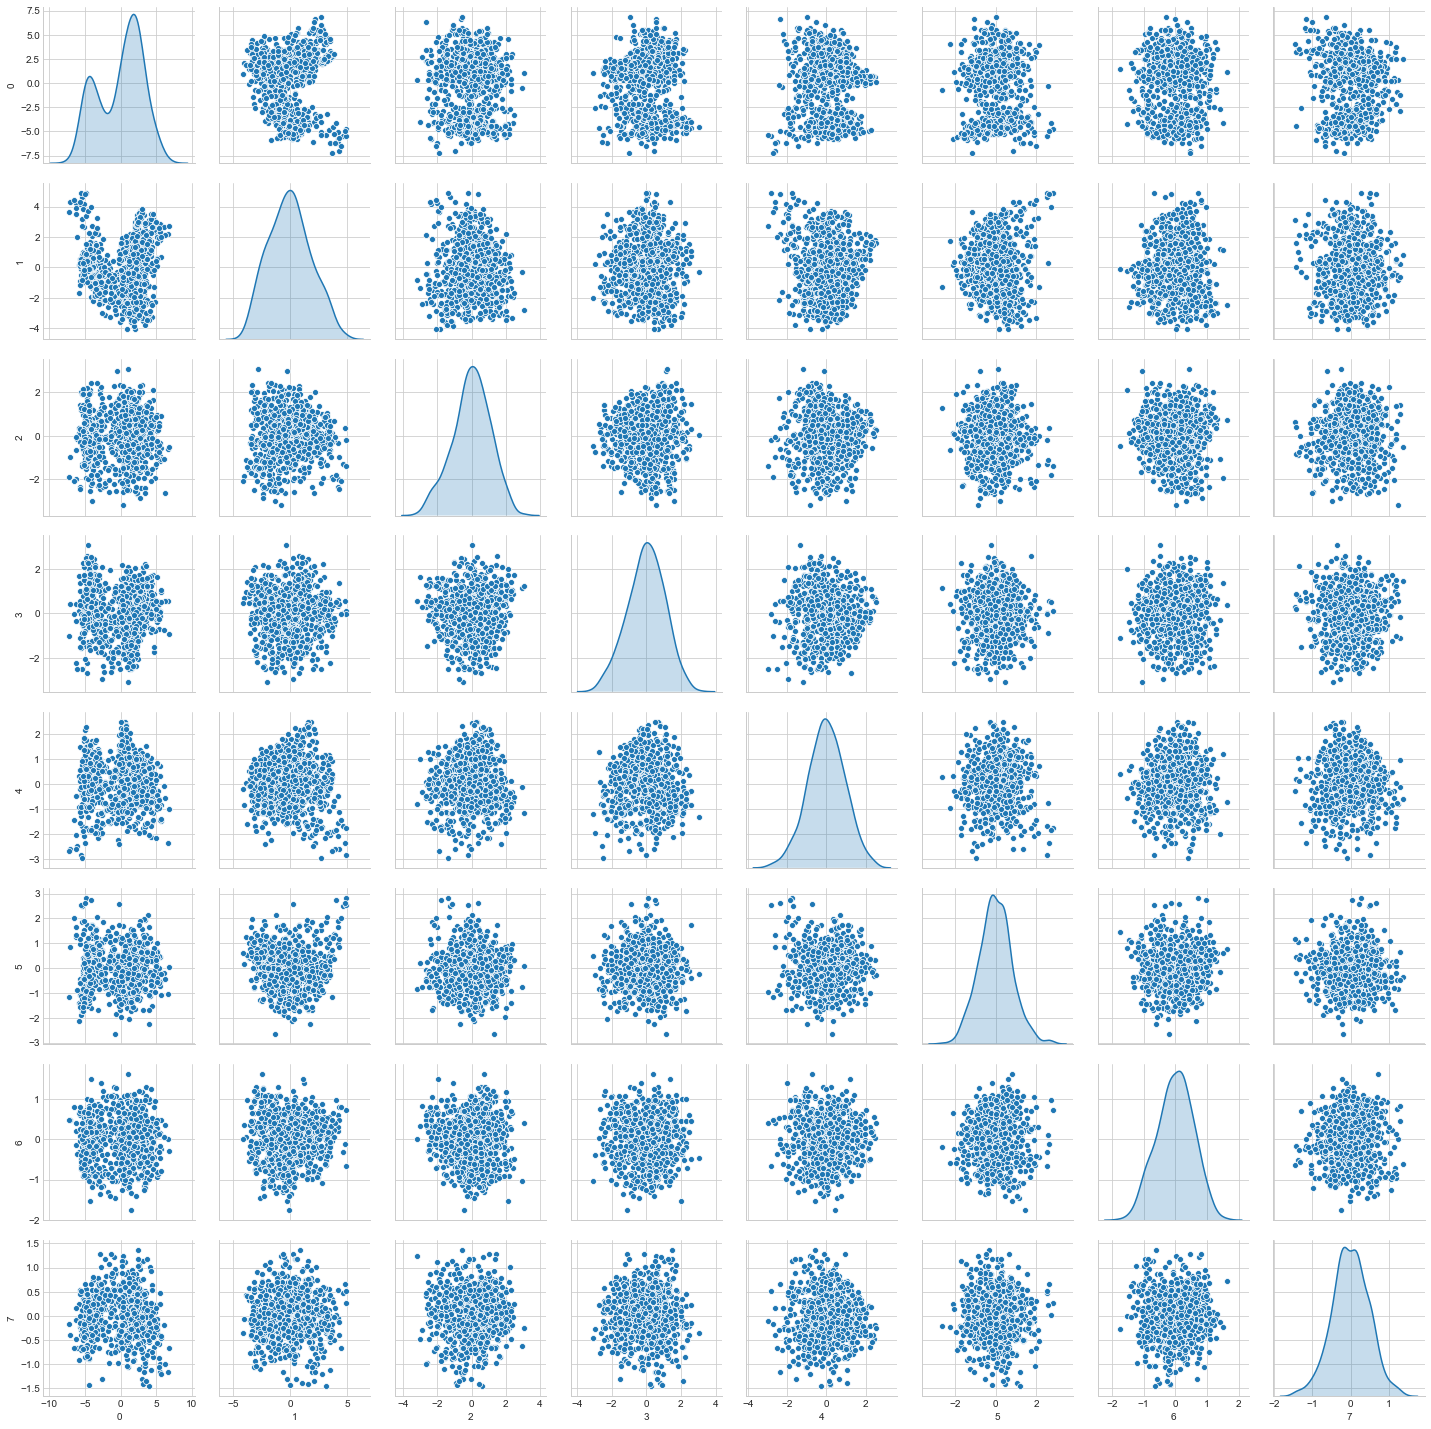

In [35]:
sns.pairplot(reduced_pca, diag_kind='kde') 

# Obseravtion 
## All the data points has become independent

# SVC Tuning with original and Dimensionality tuned data

In [36]:
Orig_X_train,Orig_X_test,Orig_y_train,Orig_y_test = train_test_split(X_std,Y,test_size=0.30,random_state=1)


pca_X_train,pca_X_test,pca_y_train,pca_y_test = train_test_split(reduced_pca,Y,test_size=0.30,random_state=1)

In [37]:
svc = SVC()

In [38]:
svc.fit(Orig_X_train,Orig_y_train)

SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
    kernel='rbf', max_iter=-1, probability=False, random_state=None,
    shrinking=True, tol=0.001, verbose=False)

In [39]:
Orig_y_predict = svc.predict(Orig_X_test)

In [40]:
svc1 = SVC() 
svc1.fit(pca_X_train,pca_y_train)


pca_y_predict = svc1.predict(pca_X_test)

In [41]:
print("Model Score On Original Data ",svc.score(Orig_X_test, Orig_y_test))
print("Model Score On Reduced PCA Dimension ",svc1.score(pca_X_test, pca_y_test))

print("Before PCA On Original 18 Dimension",accuracy_score(Orig_y_test,Orig_y_predict))
print("After PCA(On 8 dimension)",accuracy_score(pca_y_test,pca_y_predict))

Model Score On Original Data  0.9795081967213115
Model Score On Reduced PCA Dimension  0.9672131147540983
Before PCA On Original 18 Dimension 0.9795081967213115
After PCA(On 8 dimension) 0.9672131147540983


# ObSERVATION
THE ACCURACY ON 8 DIMENSION HAS NOT COME DOWN MUCH

# HYPER PARAMETER TUNING USING GRIDSEARCHCV

In [42]:
import itertools

def classifiers_hypertune(name,rf,param_grid,x_train_scaled,y_train,x_test_scaled,y_test,CV):
    CV_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=CV, verbose= 1, n_jobs =-1 )
    CV_rf.fit(x_train_scaled, y_train)
    
    y_pred_train = CV_rf.predict(x_train_scaled)
    y_pred_test = CV_rf.predict(x_test_scaled)
    
    print('Best Score: ', CV_rf.best_score_)
    print('Best Params: ', CV_rf.best_params_)
    
    
    
    
    print(name+" Classification Report: ")
    print(classification_report(y_test, y_pred_test))
    
   
    
   
    print("SVM Accuracy Score:",round(accuracy_score(y_test, y_pred_test),2)*100)

In [43]:

svmc = SVC()


print("SVM Parameters:", svmc.get_params())


param_grid = [
  {'C': [0.01, 0.05, 0.5, 1], 'kernel': ['linear']},
  {'C': [0.01, 0.05, 0.5, 1],  'kernel': ['rbf']},
 ]



SVM Parameters: {'C': 1.0, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'auto_deprecated', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [44]:
classifiers_hypertune("Support Vector Classifier", svmc, 
                      param_grid,pca_X_train, pca_y_train, 
                      pca_X_test, pca_y_test,10)

Fitting 10 folds for each of 8 candidates, totalling 80 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


Best Score:  0.9472759226713533
Best Params:  {'C': 1, 'kernel': 'rbf'}
Support Vector Classifier Classification Report: 
              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        78
         1.0       0.97      0.98      0.97       121
         2.0       0.98      0.89      0.93        45

    accuracy                           0.97       244
   macro avg       0.97      0.95      0.96       244
weighted avg       0.97      0.97      0.97       244

SVM Accuracy Score: 97.0


[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  57 out of  80 | elapsed:    3.2s remaining:    1.3s
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:    3.2s finished
/usr/local/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_search.py:814: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


In [45]:
Orig_X_train,Orig_X_test,Orig_y_train,Orig_y_test

classifiers_hypertune("Support Vector Classifier with Original dataset", svmc, 
                      param_grid,Orig_X_train, Orig_y_train, 
                      Orig_X_test, Orig_y_test,10)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


Fitting 10 folds for each of 8 candidates, totalling 80 fits
Best Score:  0.9630931458699473
Best Params:  {'C': 1, 'kernel': 'rbf'}
Support Vector Classifier with Original dataset Classification Report: 
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99        78
         1.0       0.98      0.98      0.98       121
         2.0       0.98      0.93      0.95        45

    accuracy                           0.98       244
   macro avg       0.98      0.97      0.98       244
weighted avg       0.98      0.98      0.98       244

SVM Accuracy Score: 98.0


[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:    0.2s finished
/usr/local/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_search.py:814: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


# Observations : Now SVM Accuracy score for PCA dataset has increased a bit , but so is the the Original dataset's SVM accuracy score

## Trying with other Grid let us see 

In [46]:
svmc = SVC()


print("SVM Parameters:", svmc.get_params())


param_grid_new = [
  {'C': [1, 10, 100, 1000], 'kernel': ['linear']},
  {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']},
 ]



SVM Parameters: {'C': 1.0, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'auto_deprecated', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [47]:
classifiers_hypertune("Support Vector Classifier", svmc, 
                      param_grid_new,pca_X_train, pca_y_train, 
                      pca_X_test, pca_y_test,10)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


Fitting 10 folds for each of 12 candidates, totalling 120 fits


[Parallel(n_jobs=-1)]: Done  97 out of 120 | elapsed:    0.3s remaining:    0.1s


Best Score:  0.9349736379613357
Best Params:  {'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
Support Vector Classifier Classification Report: 
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95        78
         1.0       0.97      0.93      0.95       121
         2.0       0.98      0.89      0.93        45

    accuracy                           0.95       244
   macro avg       0.95      0.94      0.94       244
weighted avg       0.95      0.95      0.95       244

SVM Accuracy Score: 95.0


[Parallel(n_jobs=-1)]: Done 120 out of 120 | elapsed:   18.0s finished
/usr/local/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_search.py:814: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


# Conlcusions : Dimensionality reduction has not reduced the SVM Accuracy score by a great margin